In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("../../data/processed.csv")
df.head(5)

,Unnamed: 0,review,model,sentiment
0,0,The movie was a complete snoozefest. I regret...,Gemini-1.5-Flash,negative
1,1,"Seriously, the worst venue I've ever been to. ...",Gemini-1.5-Flash,negative
2,2,"This event was so poorly organized, it was a j...",Gemini-1.5-Flash,negative
3,3,What a disaster of a movie! The acting was aw...,Gemini-1.5-Flash,negative
4,4,I wouldn't recommend this venue to my worst en...,Gemini-1.5-Flash,negative


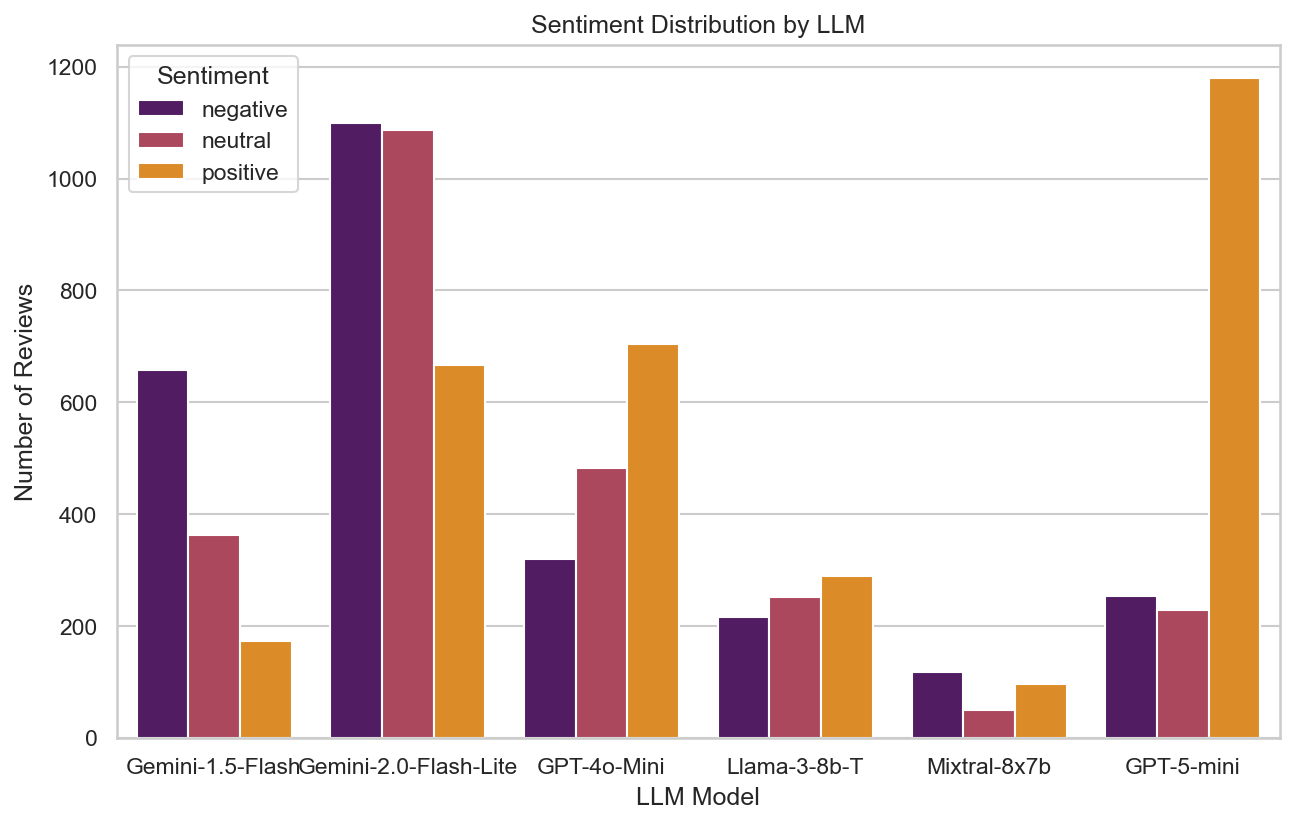

<Figure size 960x720 with 0 Axes>

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

df['review'].value_counts()

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='model', hue='sentiment', palette='inferno')
plt.title('Sentiment Distribution by LLM')
plt.xlabel('LLM Model')
plt.ylabel('Number of Reviews')
plt.legend(title='Sentiment')
plt.show()
plt.savefig('../../results/data/sentiment_plot.png', dpi=300, bbox_inches='tight')

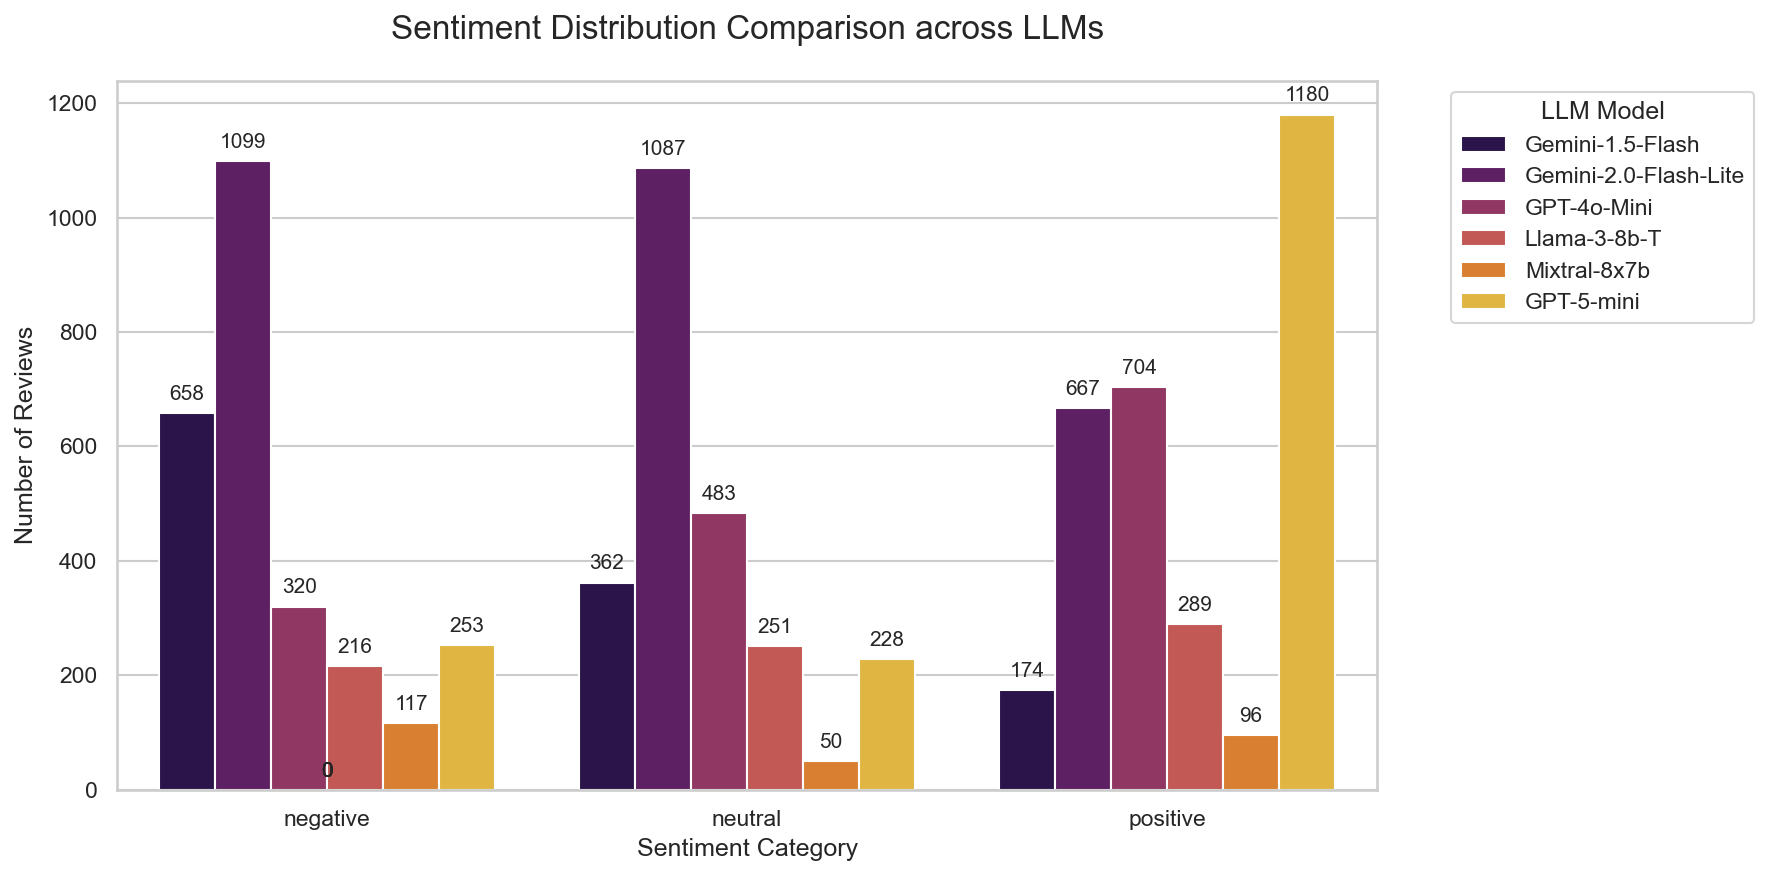

In [3]:
import matplotlib.pyplot as plt
import plotly.express as px

# 2. Set Aesthetic Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 150

# --- PLOT 1: Interleaved Count Plot (Seaborn) ---
# Shows side-by-side comparison of sentiment counts per LLM
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x='sentiment', hue='model', palette='inferno')
plt.title('Sentiment Distribution Comparison across LLMs', fontsize=16, pad=20)
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.legend(title='LLM Model', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()


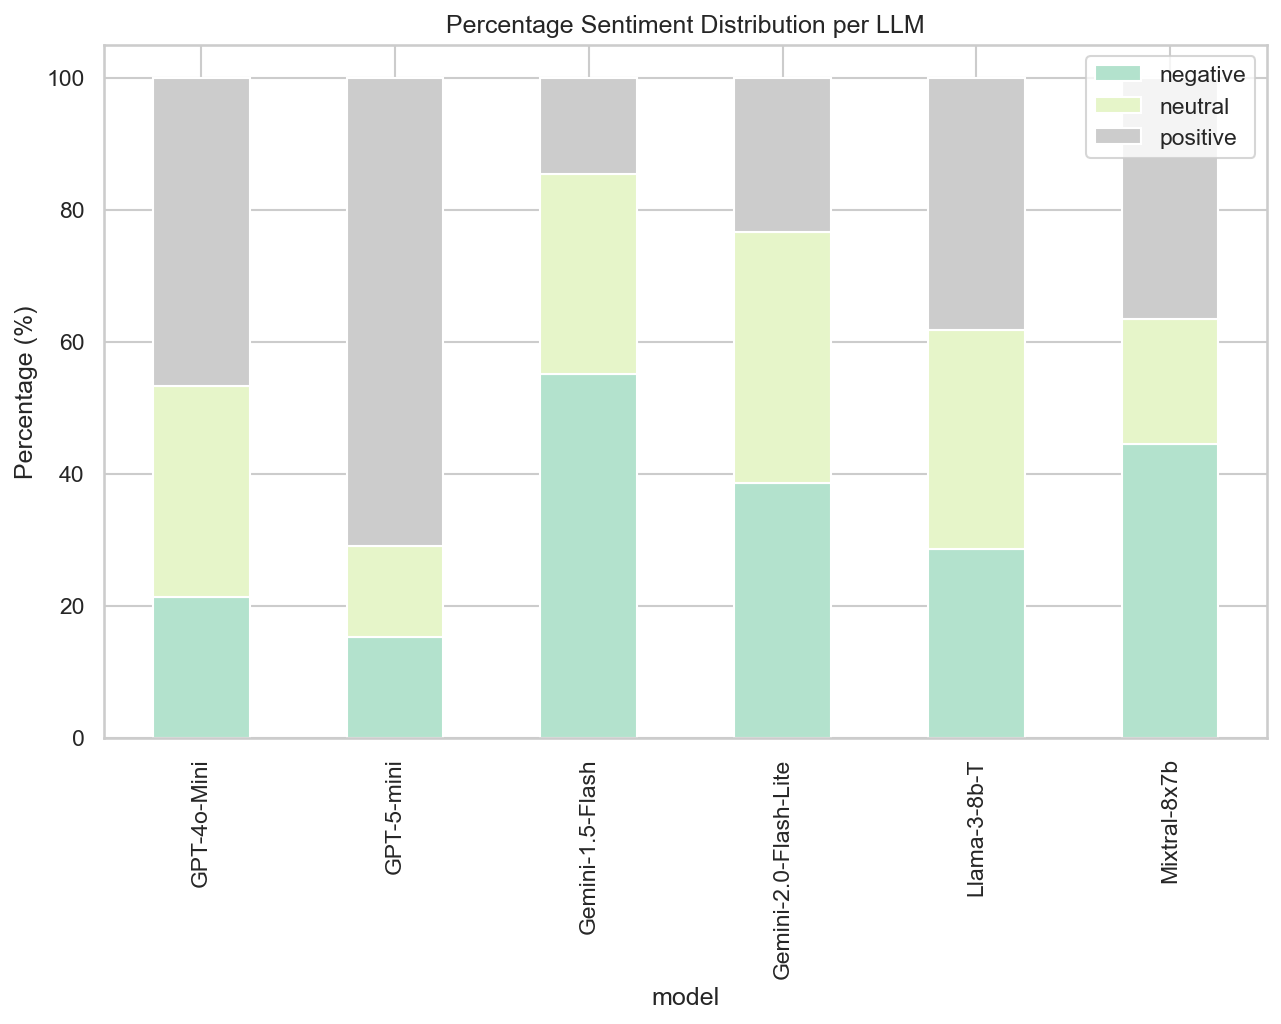

In [4]:
# Create a cross-tabulation of percentages
distribution = pd.crosstab(df['model'], df['sentiment'], normalize='index') * 100

distribution.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Pastel2')
plt.title('Percentage Sentiment Distribution per LLM')
plt.ylabel('Percentage (%)')
plt.legend(loc='upper right')
plt.show()

In [5]:
# --- PLOT 2: Interactive Sunburst Chart (Plotly) ---
# Excellent for visualizing the hierarchy: LLM -> Sentiment -> Volume
fig = px.sunburst(df, path=['model', 'sentiment'],
                  color='sentiment',
                  color_discrete_map={'Positive':'#2ecc71', 'Neutral':'#f1c40f', 'Negative':'#e74c3c'},
                  title="Interactive LLM-Sentiment Hierarchy")
fig.update_layout(margin=dict(t=40, l=0, r=0, b=0))
fig.show()

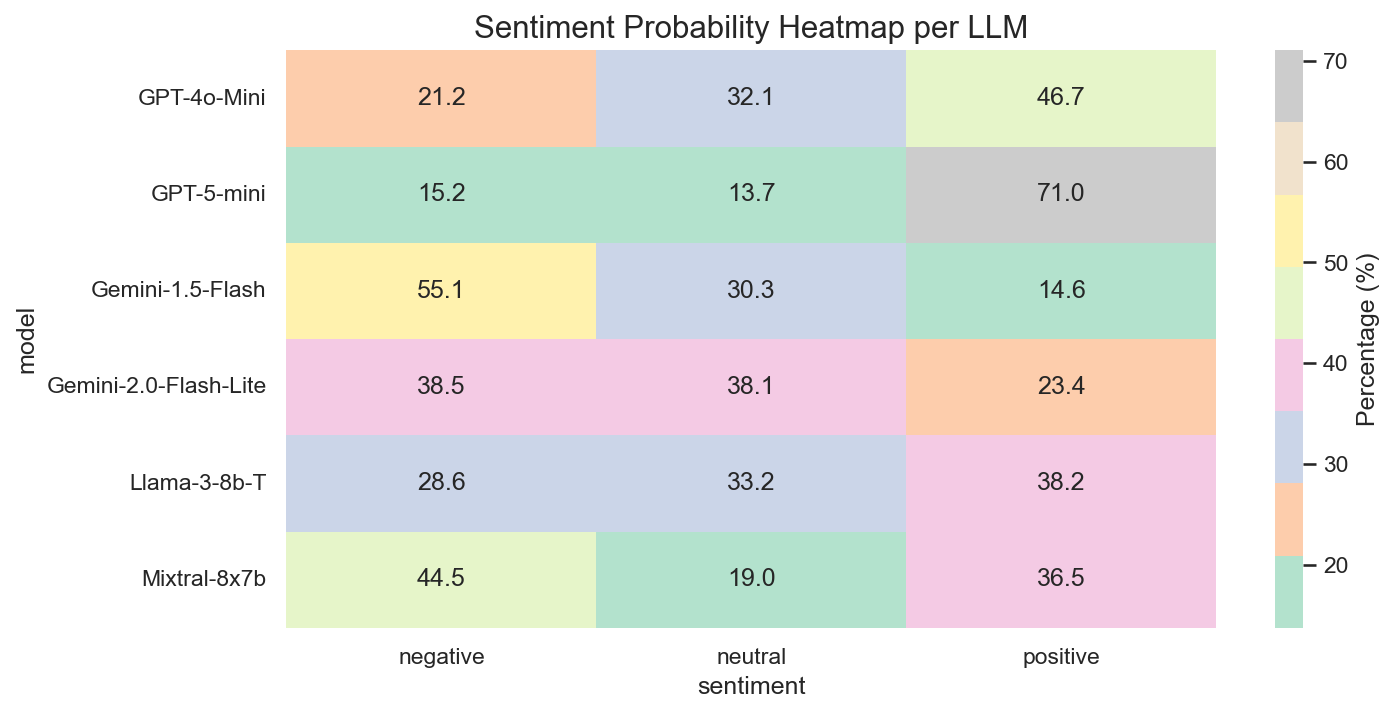

In [6]:

# --- PLOT 3: Normalized Heatmap (Heatmap of Percentages) ---
# Best for seeing if one LLM is "biased" towards a specific sentiment
ct = pd.crosstab(df['model'], df['sentiment'], normalize='index') * 100
plt.figure(figsize=(10, 5))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Pastel2", cbar_kws={'label': 'Percentage (%)'})
plt.title('Sentiment Probability Heatmap per LLM', fontsize=15)
plt.show()

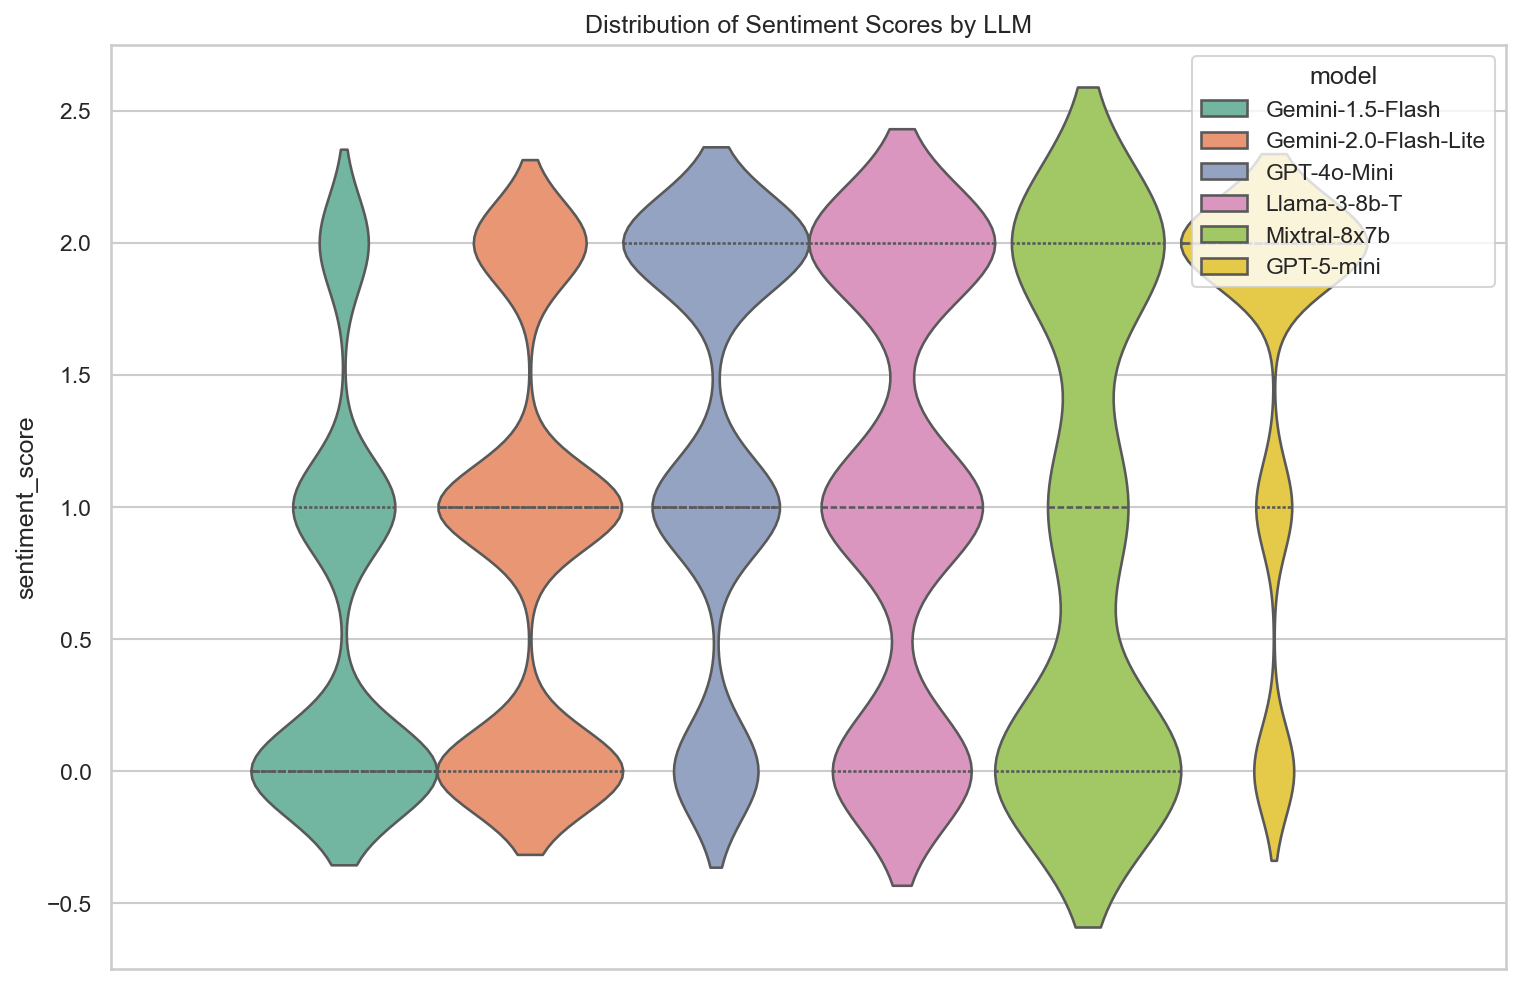

In [7]:
# Calculate review length
df['review_len'] = df['review'].apply(len)

sentiment_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['sentiment_score'] = df['sentiment'].map(sentiment_map)

# Advanced Regression Plot per LLM
plt.figure(figsize=(12, 8))
sns.violinplot(hue='model', y='sentiment_score', data=df, palette="Set2", inner="quart")    # <--- Makes points transparent to show density

plt.title('Distribution of Sentiment Scores by LLM')
plt.show()

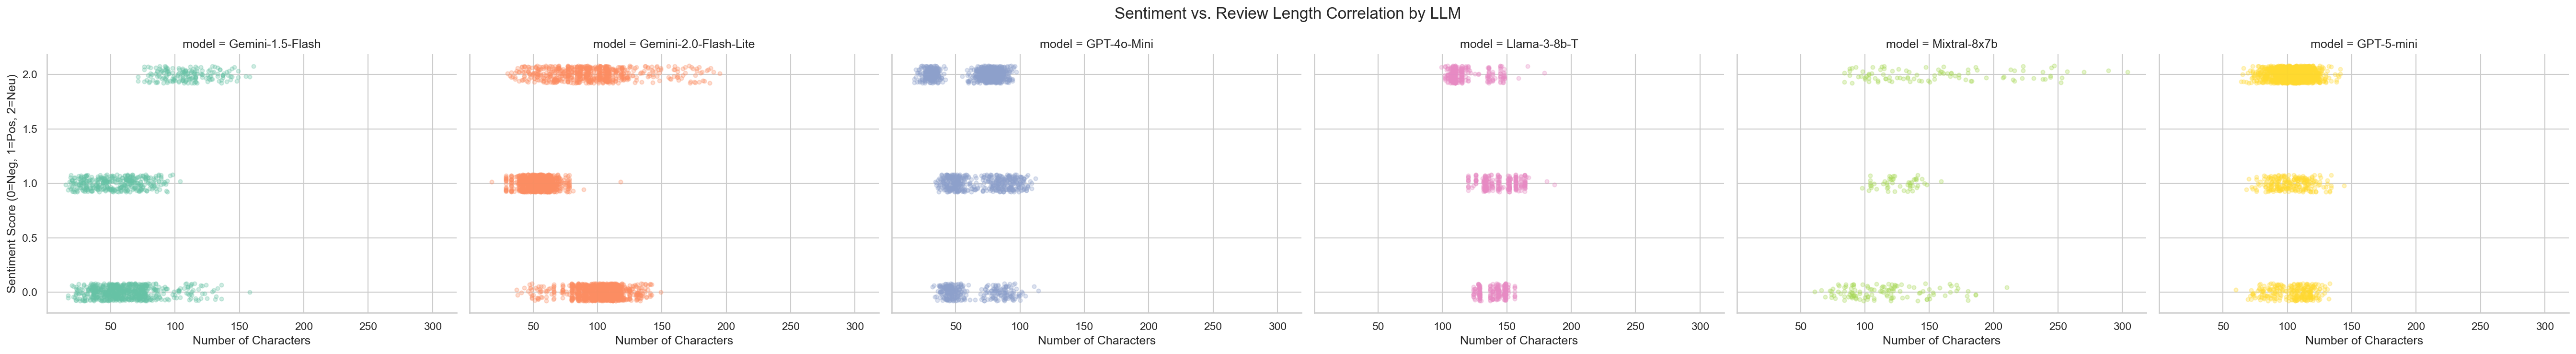

In [8]:
# 3. Plot with "Faceting" and enhanced Jitter
# We use col='llm' to create separate plots side-by-side so they don't overlap
g = sns.lmplot(
    x='review_len',
    y='sentiment_score',
    hue='model',
    col='model',             # <--- This creates 3 separate subplots (one for each LLM)
    data=df,
    palette="Set2",
    height=5,
    aspect=1.2,
    x_jitter=0.1,          # Adds a tiny bit of horizontal random noise
    y_jitter=0.08,         # Adds vertical random noise so you can see the "cloud" of points
    fit_reg=False,
    scatter_kws={
        'alpha': 0.3,      # Makes points transparent (darker areas = more reviews)
        's': 15            # Makes the points smaller so they don't merge as much
    }
)

# Customizing titles and labels
g.set_axis_labels('Number of Characters', 'Sentiment Score (0=Neg, 1=Pos, 2=Neu)')
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Sentiment vs. Review Length Correlation by LLM', fontsize=16)

plt.show()

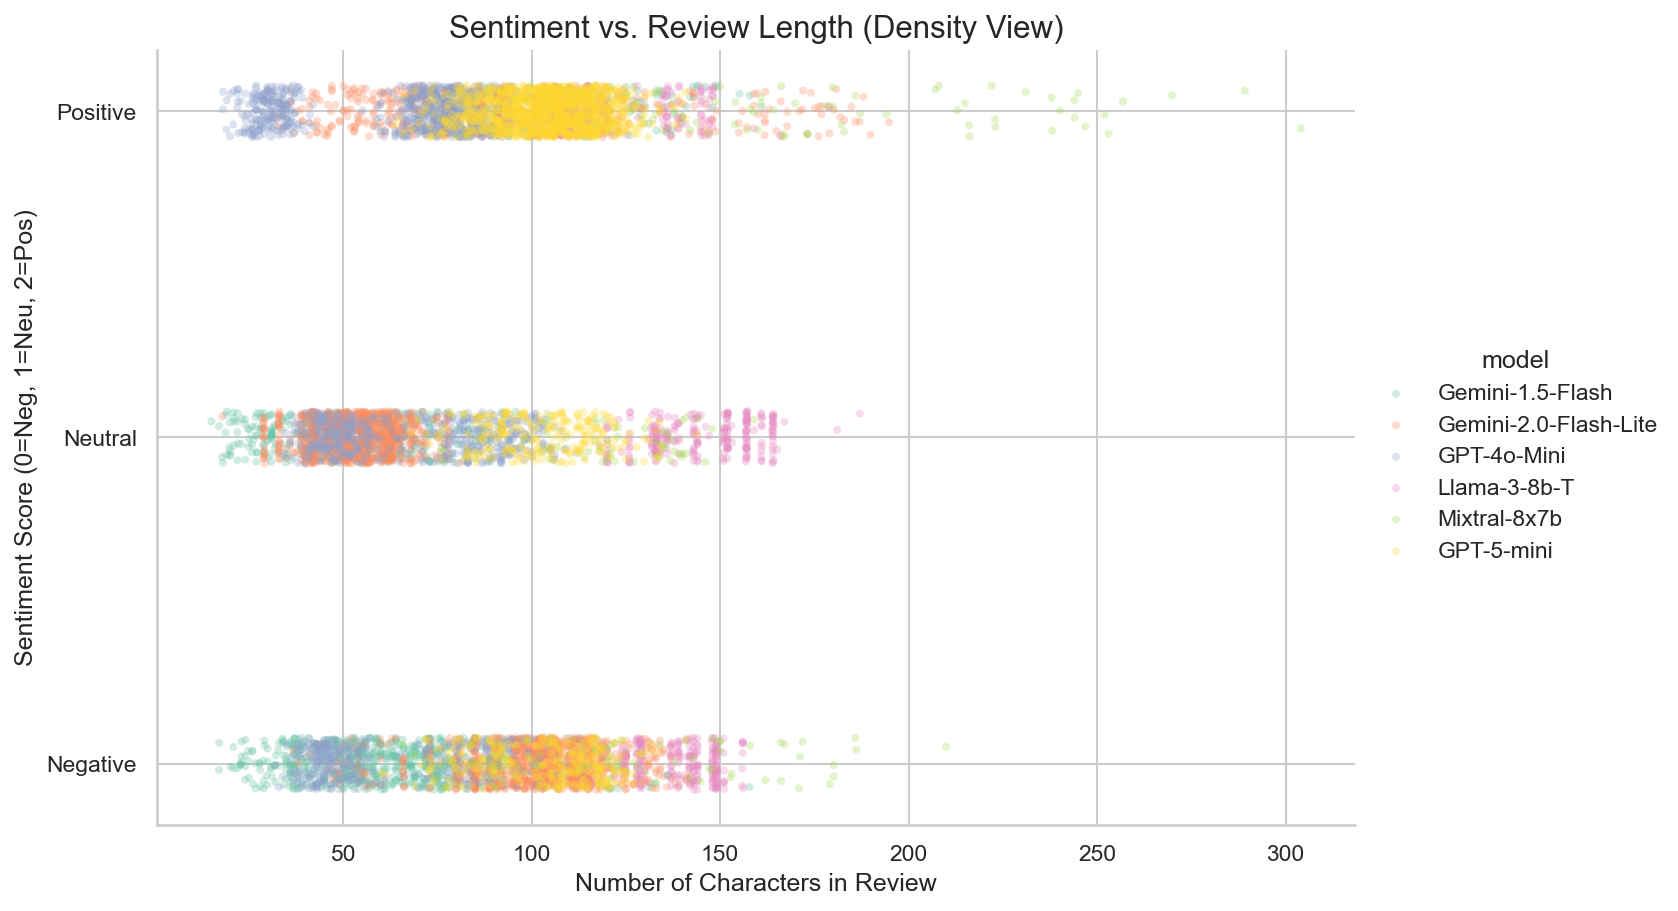

In [9]:
# 3. Enhanced Plotting to solve "Merged Points"
# We use x_jitter and y_jitter to spread points out
# scatter_kws={'s': 10} makes the points smaller
grid = sns.lmplot(
    x='review_len',
    y='sentiment_score',
    hue='model',
    data=df,
    palette="Set2",
    height=6,
    aspect=1.5,
    x_jitter=0.2,          # Spread points horizontally
    y_jitter=0.08,
    fit_reg=False,# Spread points vertically
    scatter_kws={
        'alpha': 0.3,      # High transparency to see density
        's': 15,           # Smaller point size
        'edgecolor': 'none' # Remove borders to prevent "blobbing"
    }
)

plt.title('Sentiment vs. Review Length (Density View)', fontsize=15)
plt.xlabel('Number of Characters in Review')
plt.ylabel('Sentiment Score (0=Neg, 1=Neu, 2=Pos)')

# Adjust Y-axis to show the labels clearly despite the jitter
plt.yticks([0, 1, 2], ['Negative', 'Neutral', 'Positive'])

plt.show()

<Axes: xlabel='model', ylabel='review_len'>

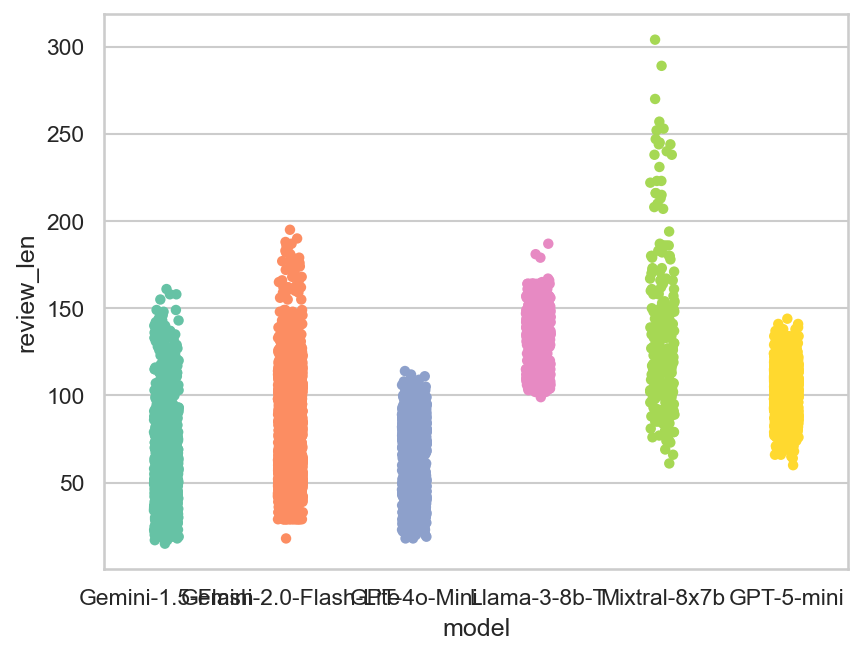

In [10]:
sns.stripplot(data=df,x='model', hue='model', y='review_len', palette="Set2")

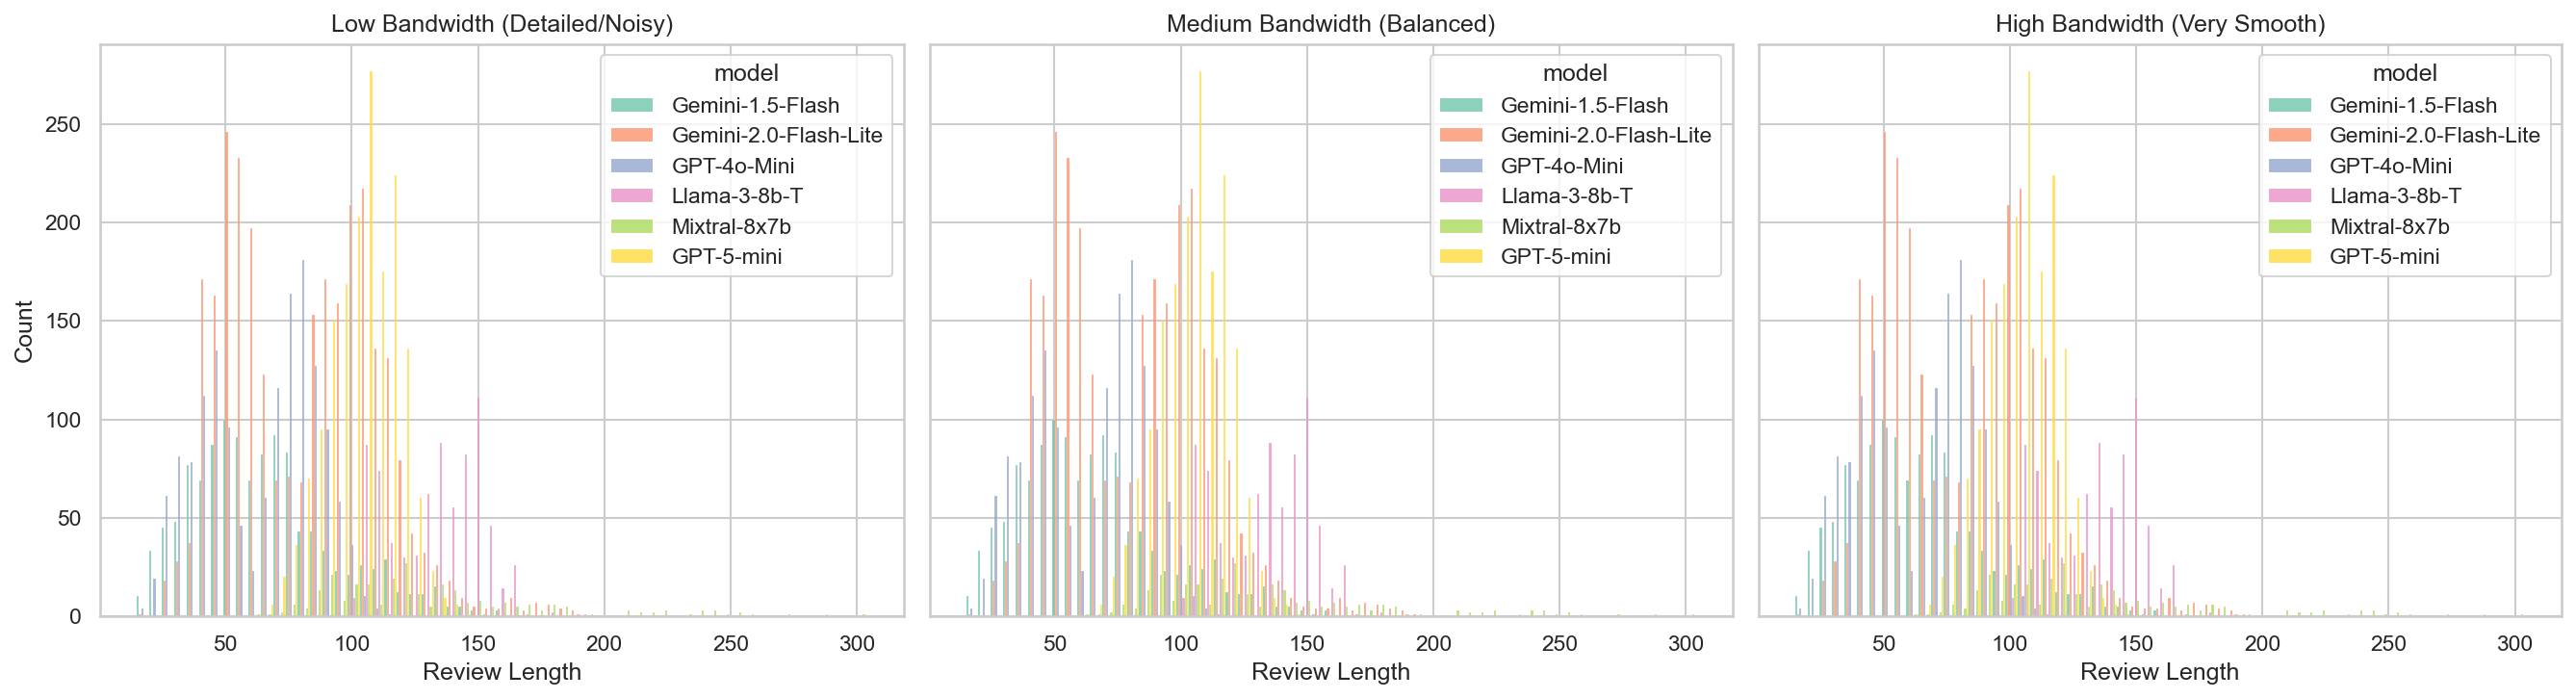

In [11]:
# We create a subplot to compare different bandwidths (smoothness)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

bandwidths = [0.2, 0.5, 1.5]
titles = ['Low Bandwidth (Detailed/Noisy)', 'Medium Bandwidth (Balanced)', 'High Bandwidth (Very Smooth)']

for ax, bw, title in zip(axes, bandwidths, titles):
    sns.histplot(
        data=df,
        x='review_len',
        hue='model',
        multiple="dodge", # Moves bars side-by-side so they don't overlap
        palette="Set2",
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('Review Length')

plt.tight_layout()
plt.show()

/var/folders/d3/7dg7gxs56r19bxqtnzvrq3km0000gn/T/ipykernel_59339/2859787289.py:11: UserWarning:

The balance properties of Sobol' points require n to be a power of 2.



<Figure size 1800x1200 with 0 Axes>

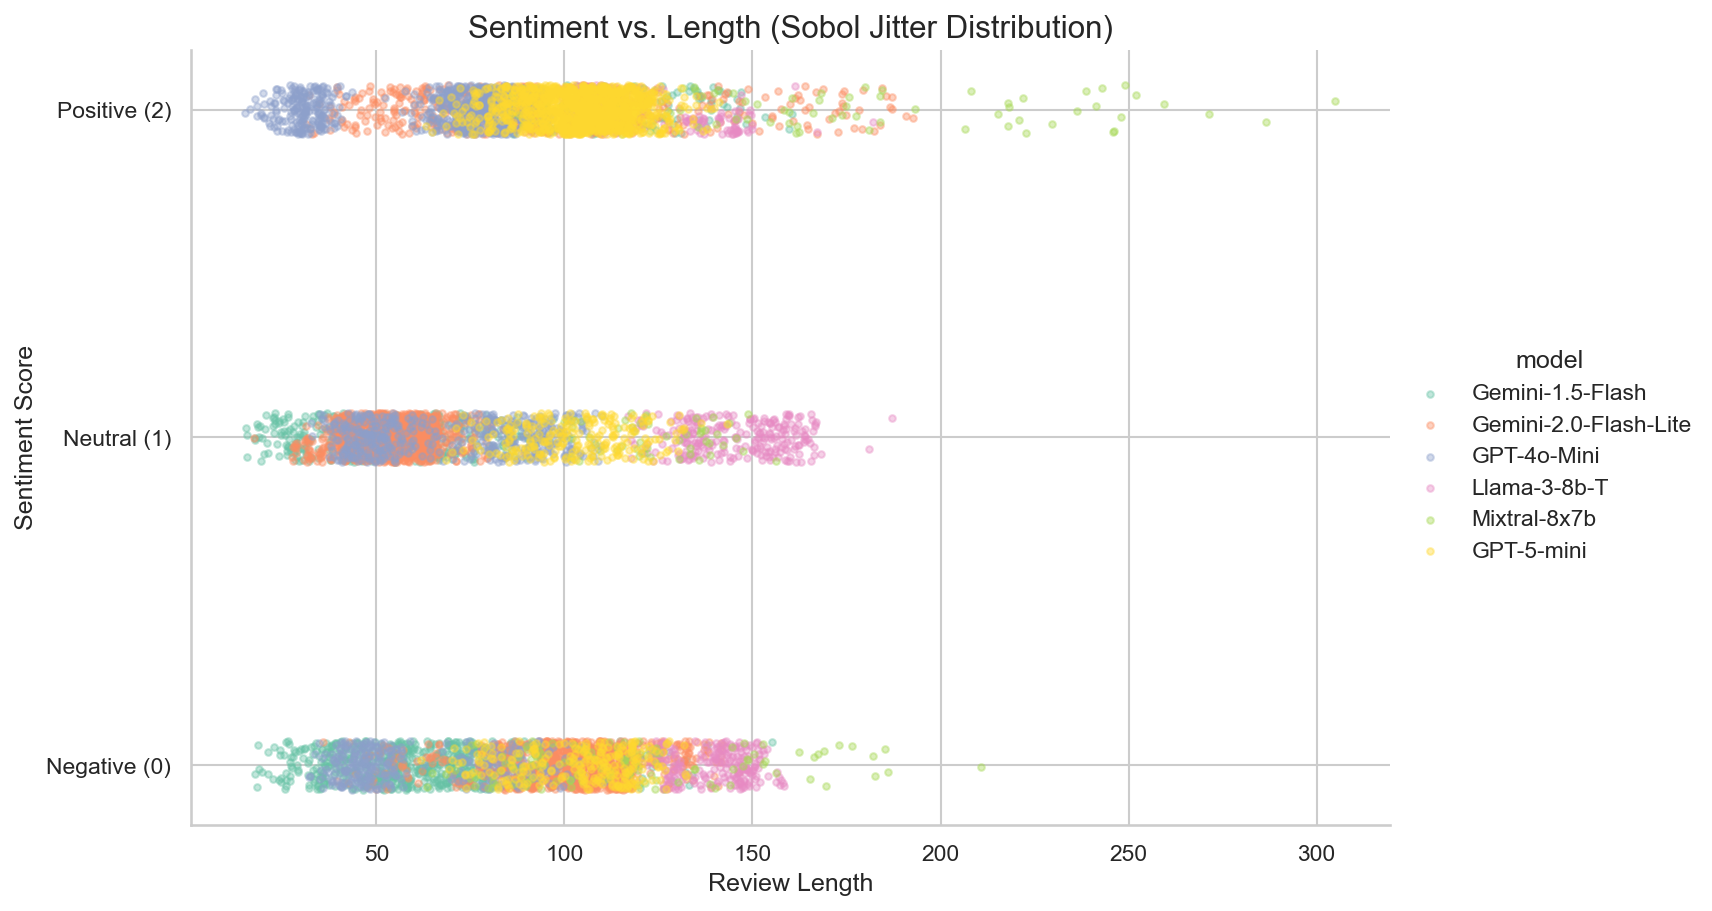

In [12]:
from scipy.stats import qmc  # For Sobol Sequences

# --- 1. Data Prep ---
df['review_len'] = df['review'].apply(len)
sentiment_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['sentiment_score'] = df['sentiment'].map(sentiment_map)

# --- 2. Generate Sobol Jitter ---
# We create a 2D Sobol sequence to "spread" the points
sampler = qmc.Sobol(d=2, scramble=True)
sample = sampler.random(n=len(df))

# Scale the Sobol noise to be small (e.g., +/- 0.05)
df['jitter_x'] = df['review_len'] + (sample[:, 0] - 0.5) * (df['review_len'].max() * 0.02)
df['jitter_y'] = df['sentiment_score'] + (sample[:, 1] - 0.5) * 0.15

# --- 3. Plotting ---
plt.figure(figsize=(12, 8))
# Use regplot or lmplot on the jittered columns
g = sns.lmplot(x='jitter_x', y='jitter_y', hue='model', data=df,
               palette="Set2", height=6, aspect=1.5,
               scatter_kws={'alpha':0.4, 's':10}, # Smaller, transparent dots
               fit_reg=False) # We disable reg here to show points clearly

# Cleanup labels so they show the original scale
plt.yticks([0, 1, 2], ['Negative (0)', 'Neutral (1)', 'Positive (2)'])
plt.title('Sentiment vs. Length (Sobol Jitter Distribution)', fontsize=15)
plt.xlabel('Review Length')
plt.ylabel('Sentiment Score')
plt.show()

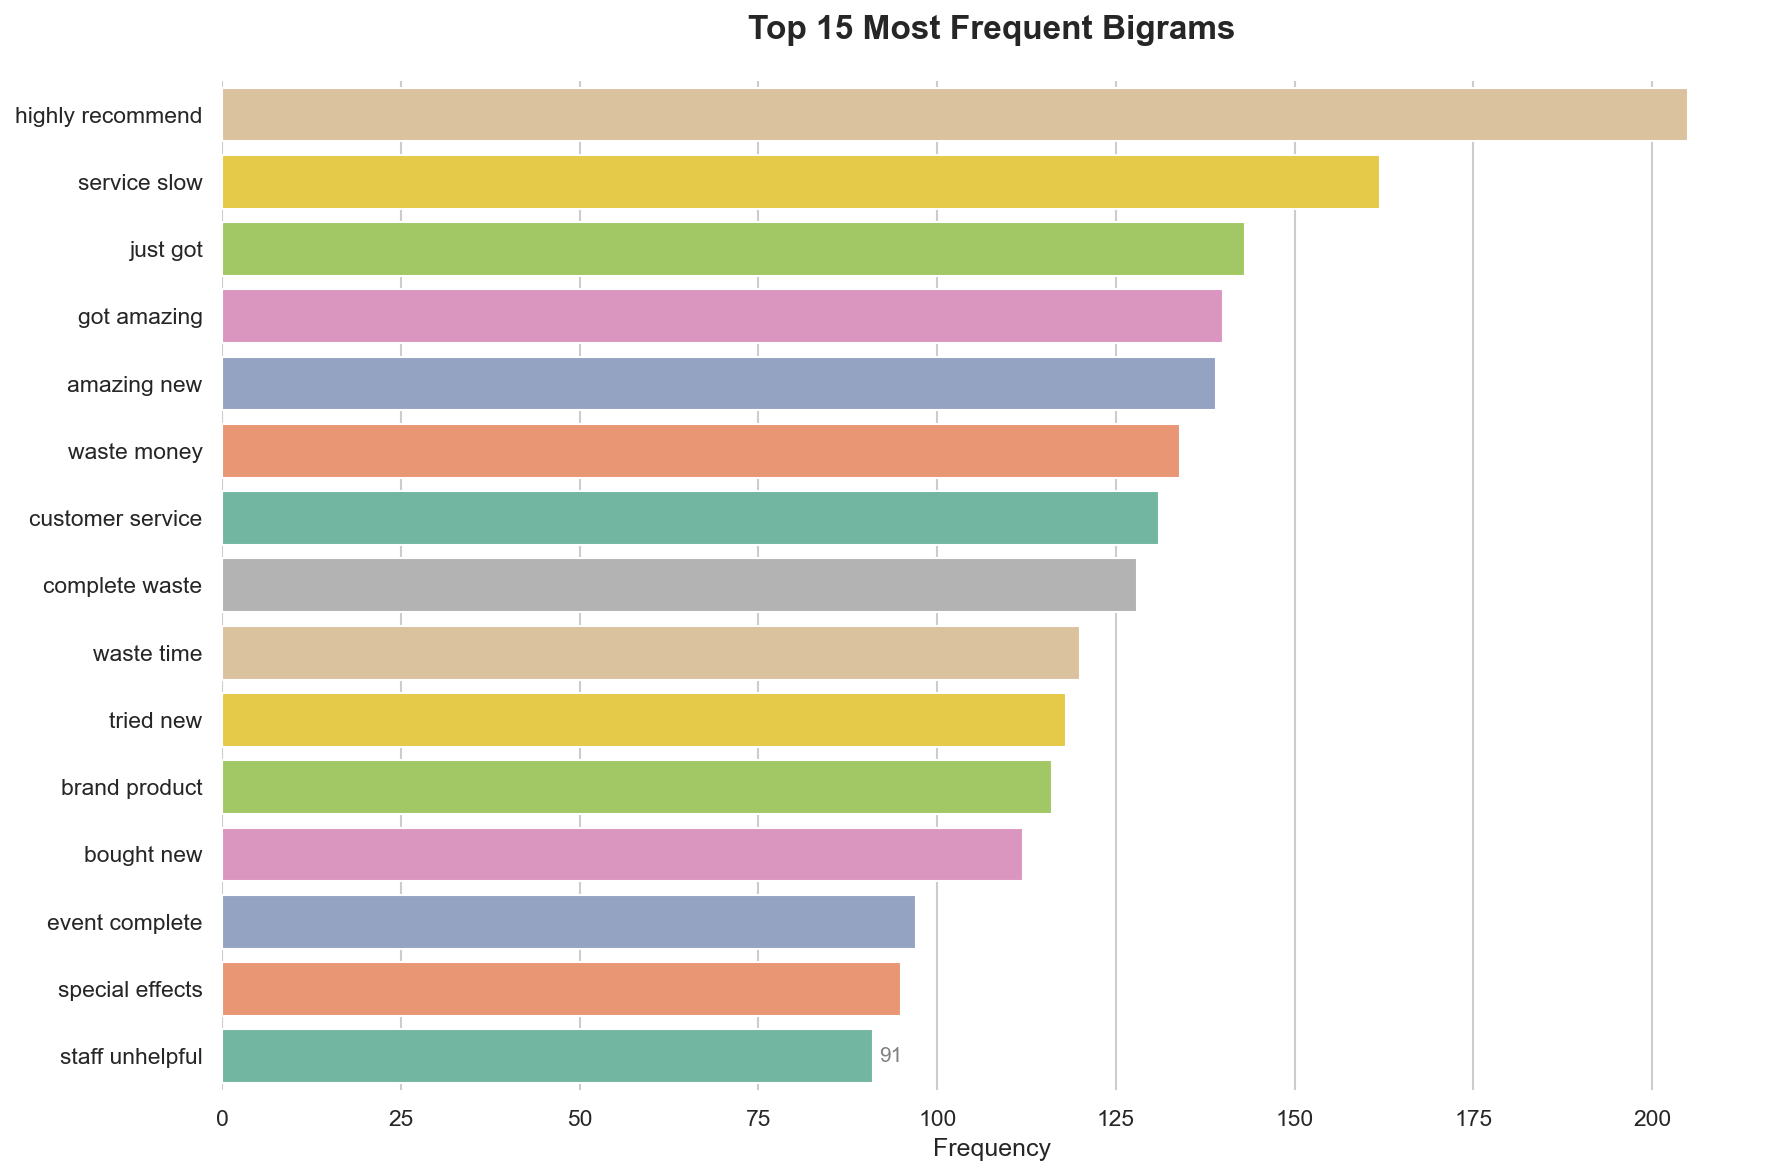

In [31]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=2, top_k=10):
    """
    Optimized n-gram extractor.
    Uses min_df to ignore extremely rare typos and better memory handling.
    """
    vec = CountVectorizer(
        ngram_range=(n, n),
        stop_words='english',
        min_df=2 # Only include n-grams that appear at least twice
    ).fit(corpus)

    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)

    # Efficiently mapping vocabulary to sums
    words_freq = [
        (word, sum_words[0, idx])
        for word, idx in vec.vocabulary_.items()
    ]

    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

# --- 1. Data Preparation ---
top_bigrams = get_top_ngrams(df['review'], n=2, top_k=15)
ngram_df = pd.DataFrame(top_bigrams, columns=['Phrase', 'Count'])

# --- 2. Advanced Plotting ---
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Use a gradient palette based on the actual values
ax = sns.barplot(
    data=ngram_df,
    x='Count',
    y='Phrase',
    hue='Count',        # Color intensity based on frequency
    palette='Set2',
    legend=False
)

# Add value labels to the end of each bar for clarity
ax.bar_label(ax.containers[0], padding=3, fontsize=10, color='gray')

# Formatting Refinement
plt.title('Top 15 Most Frequent Bigrams', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel(None) # Phrases are self-explanatory
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

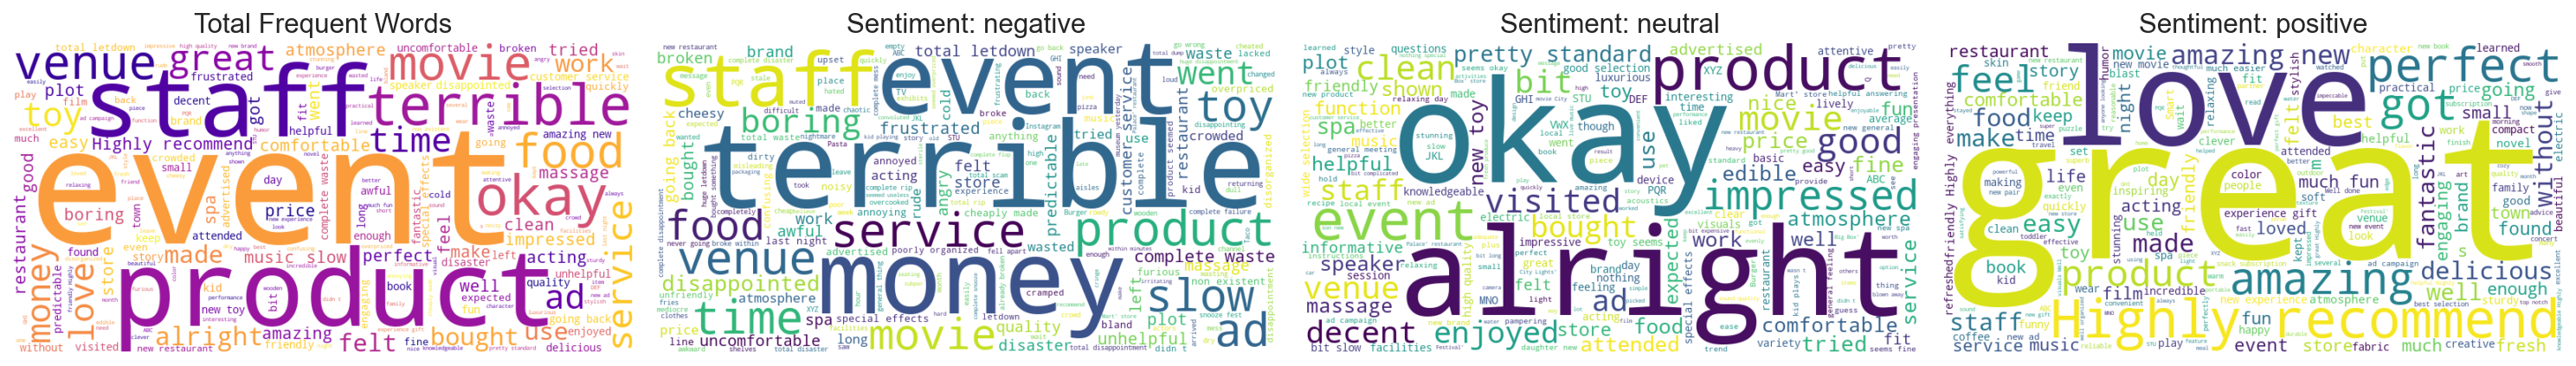

In [14]:
from wordcloud import WordCloud

def plot_wordclouds(df, text_col, sentiment_col):
    # 1. Total Word Cloud
    total_text = " ".join(review for review in df[text_col].astype(str))

    # 2. Split by Sentiment (Assuming labels like 'positive', 'negative')
    sentiments = df[sentiment_col].unique()

    # Setup plotting grid
    fig, axes = plt.subplots(1, len(sentiments) + 1, figsize=(20, 10))

    # Plot Total
    wc_total = WordCloud(width=800, height=400, background_color='white', colormap='plasma').generate(total_text)
    axes[0].imshow(wc_total, interpolation='bilinear')
    axes[0].set_title('Total Frequent Words', fontsize=15)
    axes[0].axis('off')

    # Plot per Sentiment
    for i, s in enumerate(sentiments):
        s_text = " ".join(review for review in df[df[sentiment_col] == s][text_col].astype(str))
        wc_s = WordCloud(width=800, height=400, background_color='white').generate(s_text)

        axes[i+1].imshow(wc_s, interpolation='bilinear')
        axes[i+1].set_title(f'Sentiment: {s}', fontsize=15)
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()

# Execute
plot_wordclouds(df, 'review', 'sentiment')

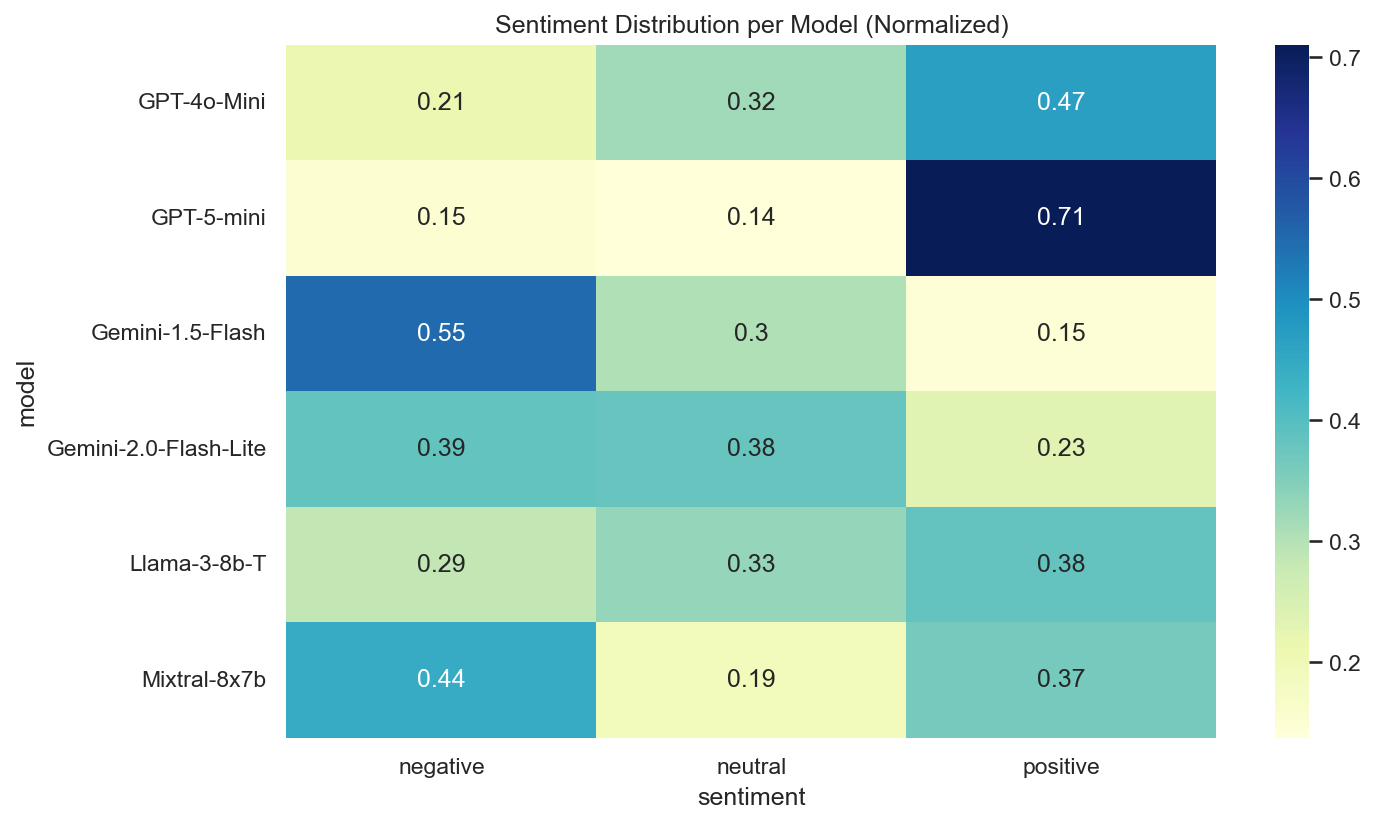

In [17]:
import pandas as pd
# Cross-tabulation of Model vs Sentiment
pivot = pd.crosstab(df['model'], df['sentiment'], normalize='index')

# Heatmap of distribution
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, cmap='YlGnBu')
plt.title("Sentiment Distribution per Model (Normalized)")
plt.show()

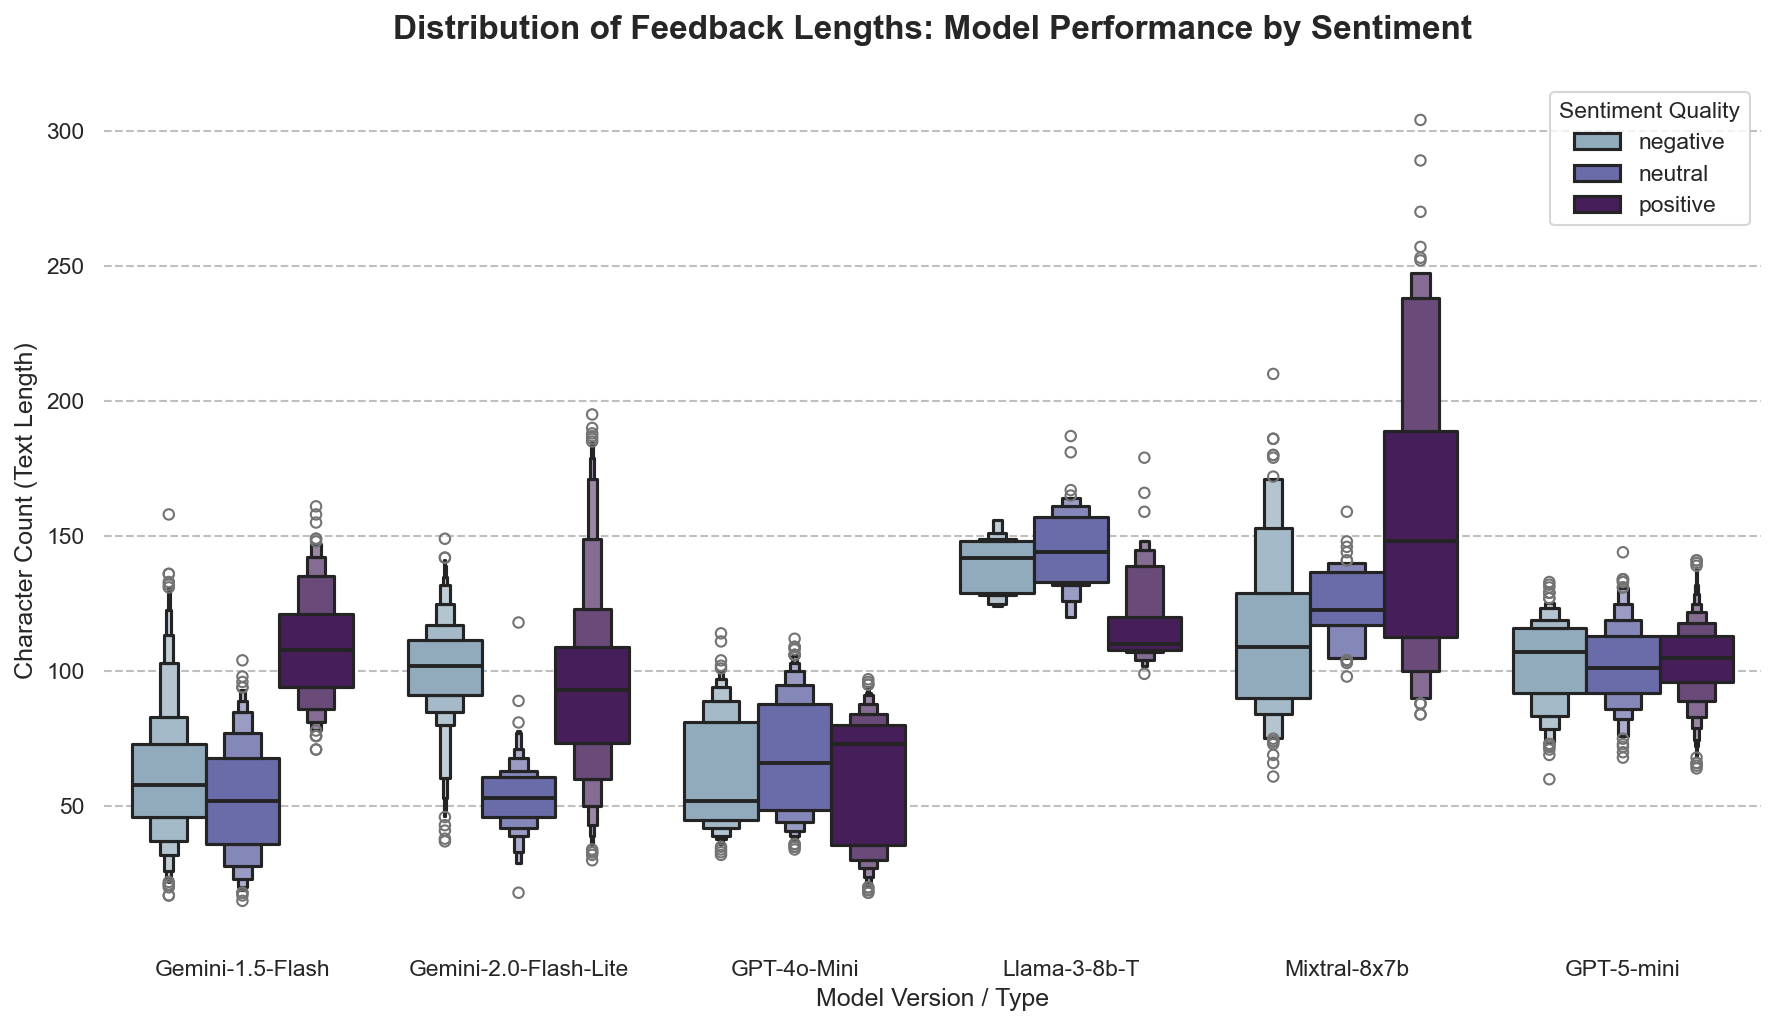

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup and Styling
sns.set_theme(style="whitegrid", palette="twilight")
plt.figure(figsize=(12, 7))

# 2. Calculate text length (if not already done)
df['text_len'] = df['review'].astype(str).apply(len)

# 3. Create an advanced Boxenplot (better for varying distributions)
ax = sns.boxenplot(
    data=df,
    x='model',
    y='text_len',
    hue='sentiment',
    outlier_prop=0.01, # Limits the visual noise from extreme outliers
    linewidth=1.5
)

# 4. Refine the aesthetics
plt.title("Distribution of Feedback Lengths: Model Performance by Sentiment",
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Model Version / Type", fontsize=12)
plt.ylabel("Character Count (Text Length)", fontsize=12)

# 5. Advanced Legend Placement & Labels
plt.legend(title="Sentiment Quality", title_fontsize='11', loc='upper right', frameon=True)

# 6. Log Scale (Optional but Recommended)
# If some models have 100 chars and others have 5000, use a log scale to see detail
# plt.yscale("log")

# 7. Add Horizontal Gridlines for readability
ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=.5)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

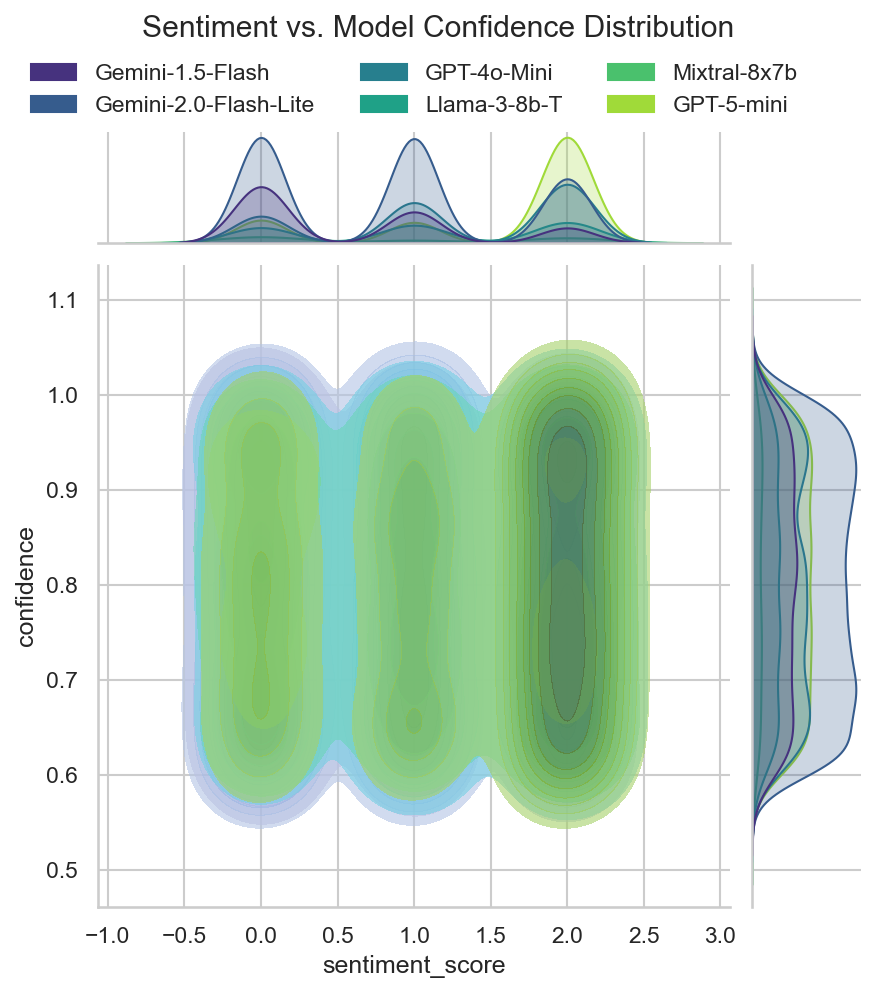

In [26]:

# Simulating confidence scores
df['confidence'] = np.random.uniform(0.6, 1.0, 8234)

# Advanced Joint Distribution Plot
g = sns.jointplot(
    data=df,
    x="sentiment_score",
    y="confidence",
    hue="model",
    kind="kde", # Kernel Density Estimate for "clouds" of data
    fill=True,
    alpha=0.6,
    palette='viridis',
)

# Remove the default legend and create a new one at the top
sns.move_legend(g.ax_joint, "lower center", bbox_to_anchor=(0.5, 1.2), ncol=3, title=None, frameon=False)

g.fig.suptitle("Sentiment vs. Model Confidence Distribution", y=1.1)
plt.show()
